# ***Data Cleaning + Regressions***

In [25]:
# Import packages
import numpy as np
import pandas as pd
import os 
from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

In [10]:
# Set directory for raw data, download raw data
brfss_raw_dir = '{}/data/BRFSS2023.csv'.format(os.getcwd())
brfss_raw_df = pd.read_csv(brfss_raw_dir)

In [11]:
# Only select columns of interest
brfss_df = brfss_raw_df[['addepev3', 'firearm5', '_ment14d', 'menthlth', '_age80', 'sexvar', '_racegr3', 'primins1', 'educa', 'income3', 'loadulk2', 'children', '_state']]

# Create a new data table from the subsetted data
brfss_dir = '{}/data/BRFSS_subset.csv'.format(os.getcwd())
brfss_df.to_csv(path_or_buf = brfss_dir, index=False)

In [12]:
# List columns and examine first few rows
print(brfss_df.columns.tolist())
brfss_df.head()

['addepev3', 'firearm5', '_ment14d', 'menthlth', '_age80', 'sexvar', '_racegr3', 'primins1', 'educa', 'income3', 'loadulk2', 'children', '_state']


,addepev3,firearm5,_ment14d,menthlth,_age80,sexvar,_racegr3,primins1,educa,income3,loadulk2,children,_state
0,2.0,NaN,1,88.0,80,2,1.0,3.0,5.0,99.0,NaN,88.0,1
1,1.0,NaN,1,88.0,80,2,1.0,3.0,5.0,99.0,NaN,88.0,1
2,2.0,NaN,2,2.0,80,2,2.0,3.0,4.0,2.0,NaN,88.0,1
3,1.0,NaN,1,88.0,78,2,1.0,3.0,5.0,99.0,NaN,88.0,1
4,1.0,NaN,1,88.0,76,2,1.0,3.0,5.0,7.0,NaN,88.0,1


# **Clean Variables - addepev3, firearm5, loadulk2, _ment14d, _racegr3, primins1, educa, income3, children** 

In [13]:
# ADDEPEV3 (Depression): Set No (2) to No (0)
                       # Set Don't know (7) and Refused (9) to missing
brfss_df['addepev3'] = brfss_df['addepev3'].replace({2:0,
                                                     7: np.nan, 9: np.nan})

# FIREARM5 (Firearms): Set No (2) to No (0)
                     # Don't Know (7) and Refused (9) to missing
brfss_df["firearm5"] = brfss_df["firearm5"].replace({2:0,
                                                     7: np.nan, 9: np.nan})

# LOADULK2 (Unlocked loaded firearms): Set No (2) to No (0) 
                                     # Don't know (7) and Refused (9) to missing 
brfss_df["loadulk2"] = brfss_df["loadulk2"].replace({2:0,
                                                     7: np.nan, 9: np.nan})

# _AGE80 (Age collapsed above 80): No Missingness

# SEXVAR (Sex): No Missingness

# MENTHLTH (Days of Poor Mental Health): Set Don't know/Not Sure/Refused (9) to missing 
brfss_df["menthlth"] = brfss_df["menthlth"].replace({77: np.nan,
                                                     88: 0,
                                                    99: np.nan})

# _RACEGR3 (Racial group): Set Don't know/Not Sure/Refused (9) to missing
brfss_df["_racegr3"] = brfss_df["_racegr3"].replace({9: np.nan})

# PRIMINS1 (Insurance group): Set employer-sponsored (1) and other private (2) to private (1).
                            # Set Medicare (3), Medigap (4), Medicaid (5), and CHIP (6) to public (2). 
                            # Set military (7), Indian Health Services (8), state-sponsored (9), and other government (10) to other (3)
                            # Set no coverage (88) to uninsured (4) 
                            # Set Don't know/Not Sure (77) and Refused (99) to missing
brfss_df["primins1"] = brfss_df["primins1"].replace({2:1,
                                                     3:2, 4:2, 5:2, 6:2,
                                                     7:3, 8:3, 9:3, 10:3,
                                                     88:4,
                                                     77:np.nan, 99:np.nan})

# EDUCA (Education level): Set never attended (1), elementary (2), some high school (3), and high school/GED (4) to high school or less (1)
                         # Set some college/trade school (5) to some college (2) 
                         # Set 4-year degreee or more (6) to Bachelor's or more (3) 
                         # Set Refused (9) to missing  
brfss_df["educa"] = brfss_df["educa"].replace({2:1, 3:1, 4:1,
                                               5:2,
                                               6:3,
                                               9:np.nan})

# INCOME3 (Income categories): Set less than 10k (1), less than 15k (2), and less than 20k (3) to less than 20k (1)
                             # Set less than 25k (4), less than 35k (5), and less than 50k (6) to 20k - 50k (2) 
                             # Set less than 75k (7) and less than 100k (8) to 50k - 100k (3) 
                             # Set less than 150k (9) and less than 200k (10) to 100k - 200k (4)
                             # Set 200k or more (11) to 200k or more (5) 
                             # Set Don't know/Not sure (77) and Refused (99) to missing  
brfss_df["income3"] = brfss_df["income3"].replace({2:1, 3:1,
                                                   4:2, 5:2, 6:2,
                                                   7:3, 8:3,
                                                   9:4, 10:4,
                                                   11:5,
                                                   77:np.nan, 99: np.nan})

# CHILDREN (Children in home indicator): Set any positive number of children to 1. 
                                       # Set No children (88) to None (0)
                                       # Set Refused (99) to missing  
brfss_df.loc[brfss_df['children'].between(1, 87), 'children'] = 1
brfss_df["children"] = brfss_df["children"].replace({88:0,
                                                     99:np.nan})

# _STATE (FIPS code): No Missingness

C:\Users\josep\AppData\Local\Temp\ipykernel_21804\252923980.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brfss_df['addepev3'] = brfss_df['addepev3'].replace({2:0,
C:\Users\josep\AppData\Local\Temp\ipykernel_21804\252923980.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  brfss_df["firearm5"] = brfss_df["firearm5"].replace({2:0,
C:\Users\josep\AppData\Local\Temp\ipykernel_21804\252923980.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .lo

In [14]:
# Copy cleaned version of dataset
brfss_clean_df = brfss_df.copy()

# Examine distribution of each variable (including missings)
print(brfss_clean_df['addepev3'].value_counts(normalize = True, dropna = False))
print(brfss_clean_df["firearm5"].value_counts(normalize = True, dropna = False))
print(brfss_clean_df["loadulk2"].value_counts(normalize = True, dropna = False))
print(brfss_clean_df['menthlth'].describe())
print(brfss_clean_df['sexvar'].value_counts(normalize = True, dropna = False))
print(brfss_clean_df['_age80'].describe())
print(brfss_clean_df["_racegr3"].value_counts(normalize = True, dropna = False))
print(brfss_clean_df["primins1"].value_counts(normalize = True, dropna = False))
print(brfss_clean_df["educa"].value_counts(normalize = True, dropna = False))
print(brfss_clean_df["income3"].value_counts(normalize = True, dropna = False))
print(brfss_clean_df["children"].value_counts(normalize = True, dropna = False))

addepev3
0.0    0.790604
1.0    0.203426
NaN    0.005970
Name: proportion, dtype: float64
firearm5
NaN    0.827528
0.0    0.102755
1.0    0.069717
Name: proportion, dtype: float64
loadulk2
NaN    0.976821
1.0    0.012679
0.0    0.010500
Name: proportion, dtype: float64
count    425215.000000
mean          4.358383
std           8.320868
min           0.000000
25%           0.000000
50%           0.000000
75%           5.000000
max          30.000000
Name: menthlth, dtype: float64
sexvar
2    0.529723
1    0.470277
Name: proportion, dtype: float64
count    433323.000000
mean         55.375461
std          17.909598
min          18.000000
25%          41.000000
50%          58.000000
75%          71.000000
max          80.000000
Name: _age80, dtype: float64
_racegr3
1.0    0.722480
5.0    0.099893
2.0    0.075969
3.0    0.056207
4.0    0.023366
NaN    0.022085
Name: proportion, dtype: float64
primins1
1.0    0.429603
2.0    0.383631
3.0    0.091278
4.0    0.052393
NaN    0.043095
Name: p

# ***Contingency Table (1) Prevalence of Depression among Gun Owners***

In [7]:
# Crosstab between depression and firearem ownership
depr_firearms_crosstab = pd.crosstab(brfss_clean_df['addepev3'], brfss_clean_df['firearm5'], margins = True)
print(depr_firearms_crosstab)

# Proportions
depr_firearms_prop = depr_firearms_crosstab = pd.crosstab(brfss_clean_df['addepev3'], brfss_clean_df['firearm5'], normalize = 'columns') * 100
print(depr_firearms_prop)

# P-value overall
chisq_pvalue = chi2_contingency(pd.crosstab(brfss_clean_df['addepev3'], brfss_clean_df['firearm5'])).pvalue
print(chisq_pvalue)

firearm5    0.0    1.0    All
addepev3                     
0.0       33848  23767  57615
1.0       10399   6296  16695
All       44247  30063  74310
firearm5        0.0        1.0
addepev3                      
0.0       76.497842  79.057313
1.0       23.502158  20.942687
2.487206276707508e-16


20.9% of gun owners have had depression compared with 23.5% of non-gun owners. The difference in depression between gun owners and non-owners is statistically significant at the 5% level (p < 0.001). 

# ***Logistic Regression (2a) Depression ~ Gun Ownership + covariates***

In [15]:
# Outcome: ADDEPEV3 (Depression)
# Main predictor: FIREARM5 (Gun ownership)
# Covariates: _AGE80, SEXVAR, _RACEGR3, EDUCA, INCOME3, PRIMINS1, 

# Logistic Regression
data_2a = brfss_clean_df[['addepev3', 'firearm5', '_age80', 'sexvar', '_racegr3', 'educa', 'income3', 'primins1']].dropna().copy() 
logreg_2a = 'addepev3 ~ C(firearm5) + _age80 + C(sexvar) + C(_racegr3) + C(educa) + C(income3) + C(primins1)'
model_2a = smf.logit(formula = logreg_2a, data = data_2a)
results_2a = model_2a.fit()

# Show results
print(results_2a.summary())

Optimization terminated successfully.
         Current function value: 0.502693
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               addepev3   No. Observations:                59677
Model:                          Logit   Df Residuals:                    59660
Method:                           MLE   Df Model:                           16
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                 0.06869
Time:                        13:36:21   Log-Likelihood:                -29999.
converged:                       True   LL-Null:                       -32212.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.4074      0.051      7.947      0.000       0.307       0.508
C(fir

Owning a gun is associated with...

# ***Linear Regression (2b) Days of Poor Mental Health ~ Gun Ownership + covariates***

In [29]:
# Outcome: MENTHLTH (continuous, days of poor mental health)
# Main predictor: FIREARM5 (gun ownership)
# Covariates: _AGE80, SEXVAR, _RACEGR3, EDUCA, INCOME3, PRIMINS1

# Keep only needed columns and drop rows with missing values
data_2b = brfss_clean_df[['menthlth', 'firearm5', '_age80', 'sexvar',
                          '_racegr3', 'educa', 'income3', 'primins1']].dropna().copy()

# Linear regression formula
linreg_2b = 'menthlth ~ C(firearm5) + _age80 + C(sexvar) + C(_racegr3) + C(educa) + C(income3) + C(primins1)'

# OLS model
model_2b = smf.ols(formula=linreg_2b, data=data_2b)
results_2b = model_2b.fit()

# Show results
print(results_2b.summary())


                            OLS Regression Results                            
Dep. Variable:               menthlth   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.093
Method:                 Least Squares   F-statistic:                     381.6
Date:                Wed, 03 Dec 2025   Prob (F-statistic):               0.00
Time:                        19:08:46   Log-Likelihood:            -2.0747e+05
No. Observations:               59192   AIC:                         4.150e+05
Df Residuals:                   59175   BIC:                         4.151e+05
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             13.8588      0

# ***Logistic Regression (3a) Unsafe Gun Storage Practices ~ Depression + covariates***

In [19]:
# Outcome: LOADULK2 (Unsafe storage)
# Main predictor: ADDEPEV3 (0/1 Depression)
# Covariates: _age80, sexvar, _racegr3, educa, income3, primins1, children

# keep only the respondents who have guns 
gun_df = brfss_clean_df[brfss_clean_df["firearm5"] == 1].copy()
print(gun_df["firearm5"].value_counts(dropna=False))

vars_3a = ["loadulk2", "addepev3", "_age80", "sexvar", "_racegr3", "educa", "income3", "primins1", "children"] #all vars needed for model 2a

m3a = gun_df[vars_3a].dropna().copy() # drop rows with any missings in these variables

#Logistic Regression
logreg_3a = "loadulk2 ~ addepev3 + (_age80) + C(sexvar) + C(_racegr3) + C(educa) + C(income3) + C(primins1) + C(children)"

model_3a = smf.logit(formula=logreg_3a, data=m3a) #https://www.statsmodels.org/stable/generated/statsmodels.formula.api.logit.html
result_3a = model_3a.fit()

print(result_3a.summary())

firearm5
1.0    30210
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.653516
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               loadulk2   No. Observations:                 8504
Model:                          Logit   Df Residuals:                     8486
Method:                           MLE   Df Model:                           17
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                 0.05257
Time:                        13:38:26   Log-Likelihood:                -5557.5
converged:                       True   LL-Null:                       -5865.8
Covariance Type:            nonrobust   LLR p-value:                4.161e-120
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.1482      0.149    

Among adults living in homes with guns (n = 8,504), having a depression diagnosis (addepev3) is not significantly associated with unsafe gun storage after adjusting for age, sex, race/ethnicity, education, income, insurance type, and children in the home (p = 0.128).

# ***Logistic Regression (3b) Unsafe Gun Storage Practices ~ Poor Mental Health Status + covariates***

In [20]:
#Outcome: loadulk2 (unsafe storage)
#main predictor: menthlth (continuous; # days of poor mental health)
#covariates: _age80, sexvar, _racegr3, educa, income3, primins1, children

# keep only the respondents who have guns 
gun_df = brfss_clean_df[brfss_clean_df["firearm5"] == 1].copy()
print(gun_df["firearm5"].value_counts(dropna=False))

vars_3b = ["loadulk2", "menthlth", "_age80", "sexvar", "_racegr3", "educa", "income3", "primins1", "children"] #all vars needed for model 2a

m3b = gun_df[vars_3b].dropna().copy() # drop rows with any missings in these variables

#Logistirc Regression
logreg_3b = "loadulk2 ~ menthlth + C(_age80) + C(sexvar) + C(_racegr3) + C(educa) + C(income3) + C(primins1) + C(children)"

model_3b = smf.logit(formula=logreg_3b, data=m3b) #https://www.statsmodels.org/stable/generated/statsmodels.formula.api.logit.html
result_3b = model_3b.fit()

print(result_3b.summary())

firearm5
1.0    30210
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.648522
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               loadulk2   No. Observations:                 8453
Model:                          Logit   Df Residuals:                     8374
Method:                           MLE   Df Model:                           78
Date:                Wed, 03 Dec 2025   Pseudo R-squ.:                 0.05979
Time:                        13:43:48   Log-Likelihood:                -5482.0
converged:                       True   LL-Null:                       -5830.6
Covariance Type:            nonrobust   LLR p-value:                3.460e-100
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.2198      0.481    

Among adults living in homes with guns (n = 8,453), having more days of poor mental health (menthlth) was not significantly associated with unsafe gun storage once we adjusted for age, sex, race/ethnicity, education, income, insurance, and children in the home (p = 0.14).

# Map of Gun Storage and Unsafe Gun Storage Practices

In [14]:
# Sample data: state abbreviations and a value (e.g., fictional population count)
data = {
    'State': ['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD', 'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'],
    'Value': [4.9, 0.7, 7.1, 3.0, 39.5, 5.7, 3.5, 0.9, 21.4, 10.6, 1.4, 1.7, 12.6, 6.7, 3.1, 2.9, 4.4, 4.6, 1.3, 6.0, 6.8, 9.9, 5.6, 2.9, 6.1, 1.0, 1.9, 3.0, 1.3, 8.8, 2.0, 19.4, 10.4, 0.7, 11.6, 3.9, 4.2, 12.8, 1.0, 5.1, 0.8, 6.8, 28.9, 3.2, 0.6, 8.5, 7.6, 1.7, 5.8, 0.5]
}

df = pd.DataFrame(data)

# Create the choropleth map
fig = px.choropleth(df,
                    locations='State', # Column with state abbreviations
                    locationmode="USA-states", # Tells Plotly to use its built-in US state geometry
                    color='Value', # Column with the metric to color by
                    scope="usa", # Limits the map to the USA
                    color_continuous_scale="Viridis", # Choose a color scale
                    title='Sample US Map with Data'
                   )

fig.show()

# Bar charts of Adjusted Probabilities adjusted probabilities of gun ownership and unsafe gun storage by depression status and days of poor mental health

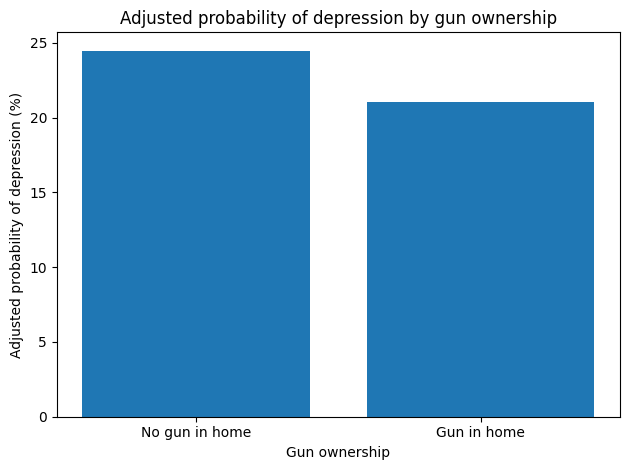

In [31]:
#Adjusted prob of depression by gun ownership

data_2a["predicted_prob_dep"] = results_2a.predict(data_2a)

prob_dep_by_gun = data_2a.groupby("firearm5")["predicted_prob_dep"].mean().reset_index() # new df storing predicted probabilty for each firearm group
prob_dep_by_gun["firearm5_label"] = prob_dep_by_gun["firearm5"].map({0: "No gun in home", 1: "Gun in home"})
prob_dep_by_gun["predicted_percent"] = prob_dep_by_gun["predicted_prob_dep"] * 100

plt.figure()

plt.bar(prob_dep_by_gun["firearm5_label"],prob_dep_by_gun["predicted_percent"])

plt.xlabel("Gun ownership")
plt.ylabel("Adjusted probability of depression (%)")
plt.title("Adjusted probability of depression by gun ownership")

plt.tight_layout()
plt.show()



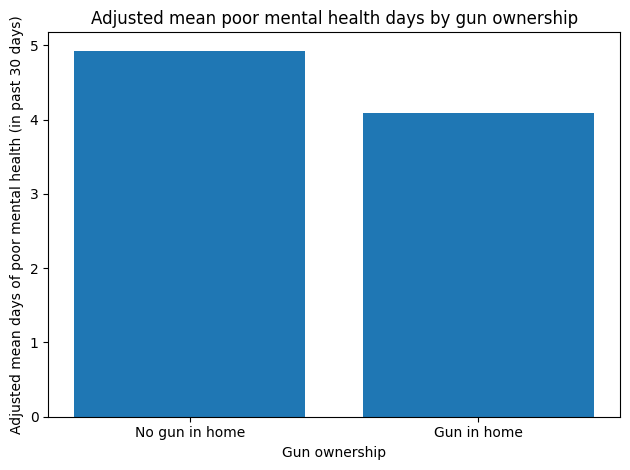

In [33]:
#Adjusted MEAN days of poor mental health by gun ownership (MENTHLTH is continuous)

data_2b["predicted_prob_menthlth"] = results_2b.predict(data_2b)

mh_by_gun = data_2b.groupby("firearm5")["predicted_prob_menthlth"].mean().reset_index()

mh_by_gun["firearm5_label"] = mh_by_gun["firearm5"].map({0: "No gun in home", 1: "Gun in home"})

plt.figure()
plt.bar(mh_by_gun["firearm5_label"], mh_by_gun["predicted_prob_menthlth"])
plt.xlabel("Gun ownership")
plt.ylabel("Adjusted mean days of poor mental health (in past 30 days)")
plt.title("Adjusted mean poor mental health days by gun ownership")
plt.tight_layout()
plt.show()


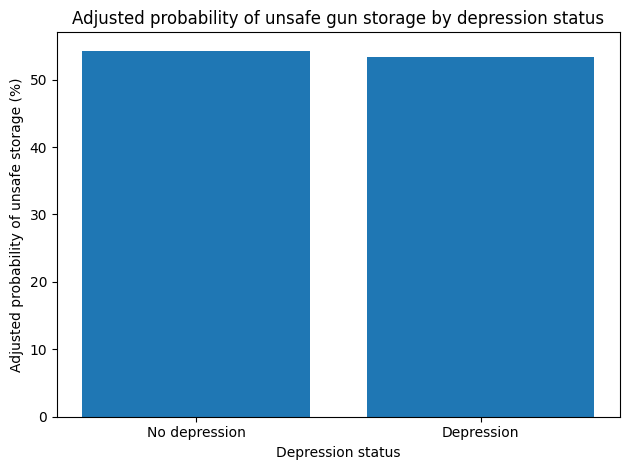

In [34]:
# Adjusted probability of unsafe gun storage by depression status

m3a["pred_prob_unsafe_dep"] = result_3a.predict(m3a)

# 2) Average predicted probability by depression status
unsafe_by_dep = m3a.groupby("addepev3")["pred_prob_unsafe_dep"].mean().reset_index()

unsafe_by_dep["dep_label"] = unsafe_by_dep["addepev3"].map({0: "No depression",1: "Depression"})
unsafe_by_dep["pred_percent"] = unsafe_by_dep["pred_prob_unsafe_dep"] * 100

plt.figure()
plt.bar(unsafe_by_dep["dep_label"], unsafe_by_dep["pred_percent"])
plt.xlabel("Depression status")
plt.ylabel("Adjusted probability of unsafe storage (%)")
plt.title("Adjusted probability of unsafe gun storage by depression status")
plt.tight_layout()
plt.show()


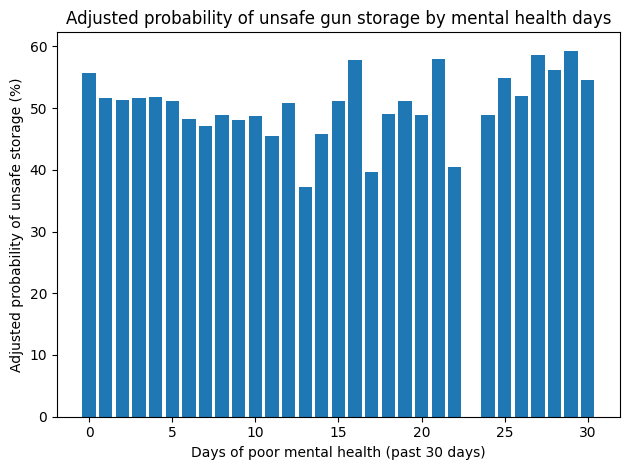

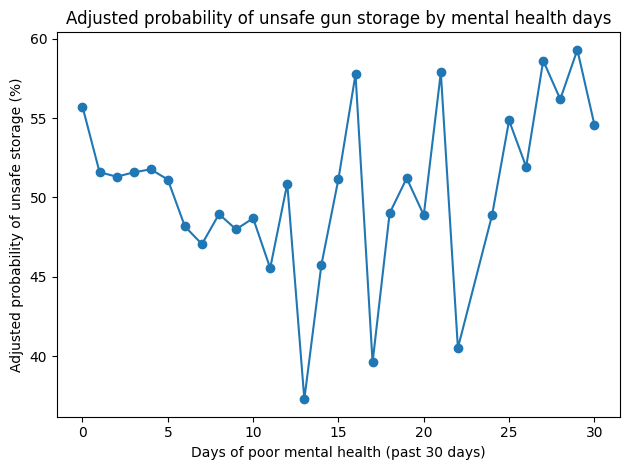

In [40]:
#Adjusted probability of unsafe gun storage by days of poor mental health 

m3b["pred_prob_unsafe_mh"] = result_3b.predict(m3b)

unsafe_by_mh = m3b.groupby("menthlth")["pred_prob_unsafe_mh"].mean().reset_index()
unsafe_by_mh["pred_percent"] = unsafe_by_mh["pred_prob_unsafe_mh"] * 100

plt.figure()
plt.bar(unsafe_by_mh["menthlth"], unsafe_by_mh["pred_percent"])
plt.xlabel("Days of poor mental health (past 30 days)")
plt.ylabel("Adjusted probability of unsafe storage (%)")
plt.title("Adjusted probability of unsafe gun storage by mental health days")
plt.tight_layout()
plt.show()



plt.figure()
plt.plot(unsafe_by_mh["menthlth"], unsafe_by_mh["pred_percent"], marker="o")
plt.xlabel("Days of poor mental health (past 30 days)")
plt.ylabel("Adjusted probability of unsafe storage (%)")
plt.title("Adjusted probability of unsafe gun storage by mental health days")
plt.tight_layout()
plt.show()
